In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../src/")

In [3]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
import shap
from joblib import dump, load
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sbn
import numpy as np

In [4]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

# eXplainable AI

Since in the model selection phase of the previous task, we have identified a RandomForestClassifier (with a specific data preprocessing step) as the best classifier for our goals, let's apply the XAI techniques to it.

## Dataset generation

Let's reconstruct the classifier.

In [5]:
from classification_utility import train_test_for_non_distance, split_in_train_and_validation

In [6]:
train_set, test_set, train_label, test_label=train_test_for_non_distance()

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


In [7]:
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

In [8]:
print(f'TRAINING (Oversampled): {train_set_os.shape[0]} - {train_label_os.shape[0]}')
print(f'TEST (Oversampled): {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING (Oversampled): 672056 - 672056
TEST (Oversampled): 32586 - 32586


In [9]:
TR_set_os, VD_set_os, TR_label_os, VD_label_os=split_in_train_and_validation(train_set_os, train_label_os)
print(f'TRAINING (Oversampled): {TR_set_os.shape[0]} - {TR_label_os.shape[0]}')
print(f'VALIDATION (Oversampled): {VD_set_os.shape[0]} - {VD_label_os.shape[0]}')
print(f'TEST (Oversampled): {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING (Oversampled): 470439 - 470439
VALIDATION (Oversampled): 201617 - 201617
TEST (Oversampled): 32586 - 32586


In [10]:
#Custom function to print the classification report con training/valid
def print_report(train_label, train_predictions, validation_label, valid_predictions, v_or_t='TEST'):
    #v_or_t to print TEST or VALIDATION RESULTS
    classes=['not top20', 'top20']
    if train_label is not None:
        print('TRAINING SET RESULTS')
        print(classification_report(train_label, train_predictions, target_names=classes))
        print('--------------------')
    print(v_or_t+' SET RESULTS')
    print(classification_report(validation_label, valid_predictions, target_names=classes))

In [11]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True)
rf = rf.fit(train_set_os, train_label_os)
train_pred_rf = rf.predict(train_set_os)
test_pred_rf = rf.predict(test_set)
print_report(train_label=train_label_os, train_predictions=train_pred_rf, validation_label=test_label, valid_predictions=test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.94      0.93    402429
       top20       0.90      0.87      0.89    269627

    accuracy                           0.91    672056
   macro avg       0.91      0.90      0.91    672056
weighted avg       0.91      0.91      0.91    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.92      0.91     28066
       top20       0.46      0.43      0.44      4520

    accuracy                           0.85     32586
   macro avg       0.68      0.67      0.68     32586
weighted avg       0.85      0.85      0.85     32586



In [12]:
# Create the SHAP explainer for the Random Forest model
rf_explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")

We were not able to define a TreeExplainer that performed an 'interventional perturbation' due to computational limitations. We will use only the 'tree_path_dependent' method instead.

In [13]:
# Determine the SHAP values for the test set
# shap_values = rf_explainer.shap_values(test_set)

In [14]:
# shap_values

In [15]:
# Save the SHAP values in a file
# dump(shap_values, "shap_values_distributional.joblib")

In [16]:
# Load the SHAP values from a file
shap_values = load("shap_values_distributional.joblib")

In [17]:
shap_values

array([[[ 0.0429741 , -0.0429741 ],
        [ 0.04785275, -0.04785275],
        [-0.0538742 ,  0.0538742 ],
        ...,
        [-0.02389954,  0.02389954],
        [-0.12365953,  0.12365953],
        [ 0.01558981, -0.01558981]],

       [[-0.02303124,  0.02303124],
        [-0.00204869,  0.00204869],
        [-0.0270597 ,  0.0270597 ],
        ...,
        [ 0.01619873, -0.01619873],
        [-0.07437197,  0.07437197],
        [-0.01384713,  0.01384713]],

       [[-0.01718087,  0.01718087],
        [ 0.01655121, -0.01655121],
        [-0.03020833,  0.03020833],
        ...,
        [ 0.00030146, -0.00030146],
        [-0.01070041,  0.01070041],
        [-0.00828825,  0.00828825]],

       ...,

       [[-0.00966793,  0.00966793],
        [ 0.04130594, -0.04130594],
        [-0.02794902,  0.02794902],
        ...,
        [ 0.01760635, -0.01760635],
        [ 0.04164181, -0.04164181],
        [-0.00664996,  0.00664996]],

       [[ 0.005622  , -0.005622  ],
        [ 0.02066057, -0.02

'shap_values' contains the SHAP values for every feature for each instance in your test set, so we can break down the contribution of every feature to every individual prediction.

## Global interpretability

In [18]:
shap_values_class_1 = shap_values[:, :, 1]  # SHAP contributions for the class '1'
print(shap_values_class_1.shape)
shap_values_class_0 = shap_values[:, :, 0]  # SHAP contributions for the class '0'
print(shap_values_class_0.shape)

(32586, 12)
(32586, 12)


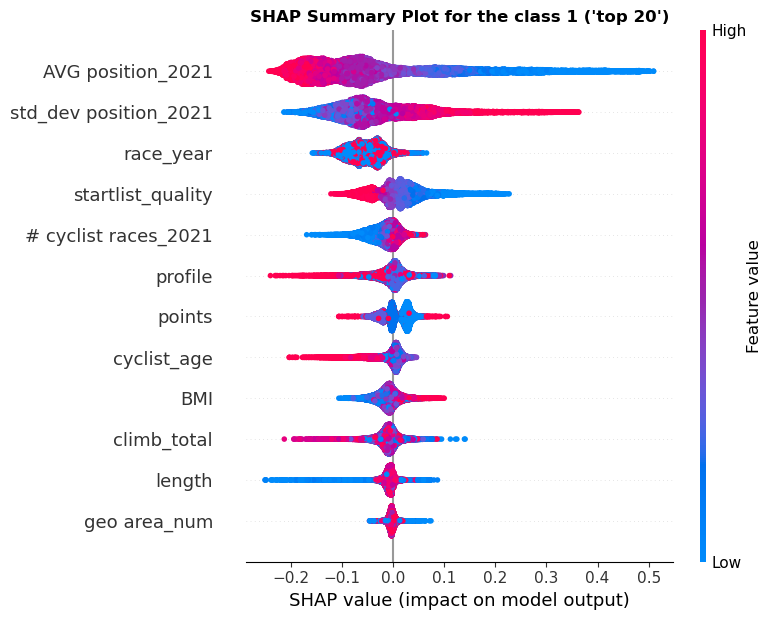

In [19]:
plt.title("SHAP Summary Plot for the class 1 ('top 20')", fontweight='bold')
shap.summary_plot(shap_values_class_1, test_set)
plt.show()
plt.close()

**SHAP Summary plot observations**
- From the SHAP summary plot we can see that the features that contribute most to the final prediction are the statistics for the races up to 2021, in particular the most influential feature is _'AVG position_2021'_. In fact, the plot shows that the instances with a very low value of AVG position have a high probability of being classified as _'top 20'_ (class 1). This is clearly an observation that makes sense, as we would expect valuable cyclists to have a low AVG position value.
- The second most impactful feature is  _'std_dev_position_2021'_ but here we have an opposite situation; for those cyclists having a lower standard deviations on their placements, there is an higher probability to be classified as _'not top 20'_ (class 0). Actually this pattern seems non sensical since we expect valuable cyclists not to have a strong variations on their placements. But on the other hand we have also to remember that most of the cyclists have performed very few races, in particular a consistent number of cyclists has only one recorded placement hence with a 0 value of std_dev.
- As for the startlist_quality feature, the lower the value, the more likely the cyclists are to be classified as top_20. This could be a reasonable result as we expect races with high values of startlist quality to attract many cyclists, thus reducing our probability of being in the top 20.

In general these 3 features are the most impactful for the model to classify the istances as 'top_20'. For the other features we notice that there is not a general trend but there are differences depending on the single instances. The 'geo area' feature is the least influent in the class assignment.

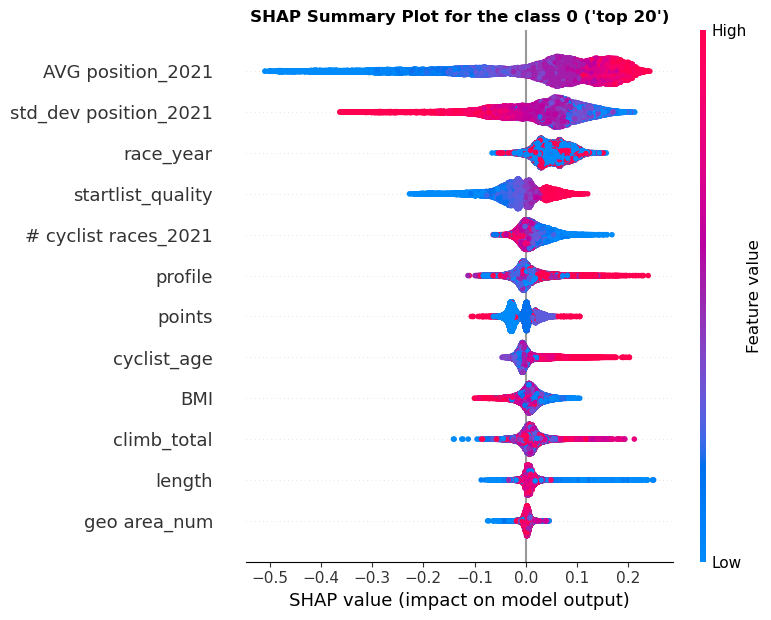

In [20]:
plt.title("SHAP Summary Plot for the class 0 ('top 20')", fontweight='bold')
shap.summary_plot(shap_values_class_0, test_set)
plt.show()
plt.close()

In [21]:
print(test_set.columns.tolist())

['cyclist_age', 'race_year', 'points', 'length', 'climb_total', 'profile', 'startlist_quality', 'BMI', 'AVG position_2021', '# cyclist races_2021', 'std_dev position_2021', 'geo area_num']


In [22]:
# Convert shap_values to shap.Explanation object
shap_values_exp = shap.Explanation(values=shap_values[:, :, 1], base_values=None, data=test_set.values, feature_names=test_set.columns)

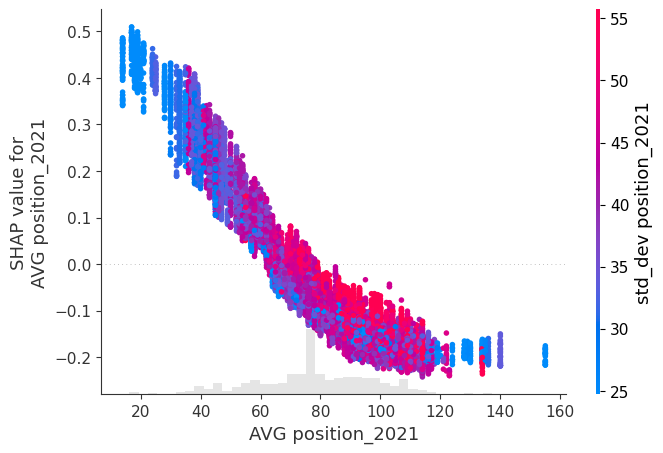

In [23]:
# Plot the scatter plot of the SHAP values for the feature 'AVG position_2021' and the feature 'std_dev position_2021'
shap.plots.scatter(shap_values_exp[:, "AVG position_2021"], color=shap_values_exp[:, "std_dev position_2021"])

- This scatterplot shows that cyclists with a very low AVG position have also a low standard deviation with a very high SHAP value for the 1 class. Also those cyclists with very high AVG position have a low standard deviation but, in this situation, there is a contribution toward the 0 class. 
- Actually those cyclists with a high standard deviation of the positions are those with an AVG position in the central part of the distribution; in this situation the standard deviation may influence the final classification, in particular high variability in the results may controbute to be classified to the 0 class.
- We can observe that for low values of the avg position there is a more evident vertical dispersion of points suggesting that, in this case, the final prevision is more dependend also on the other features.

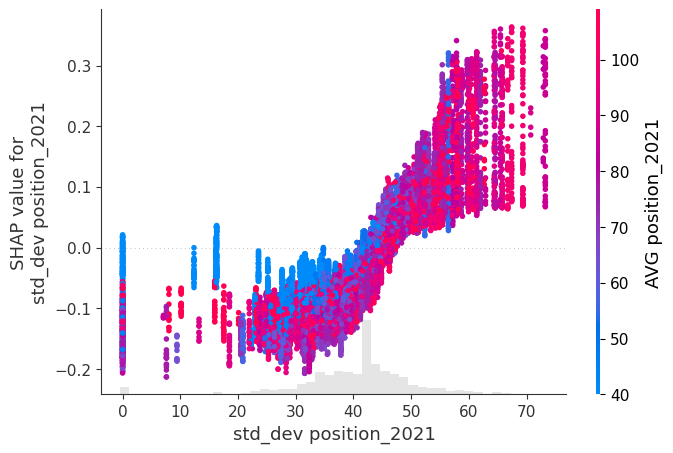

In [24]:
# Plot the scatter plot of the SHAP values for the feature 'AVG position_2021' and the feature 'std_dev position_2021'
shap.plots.scatter(shap_values_exp[:, "std_dev position_2021"], color=shap_values_exp[:, "AVG position_2021"])

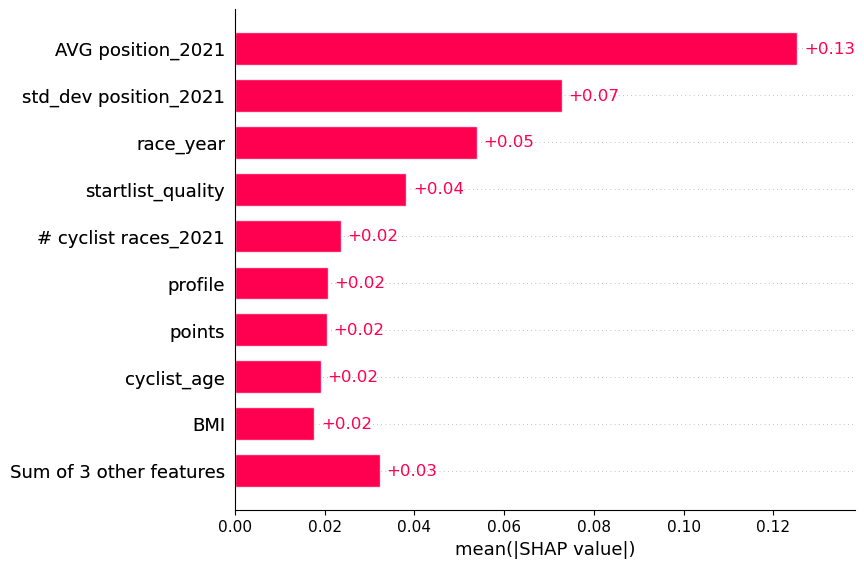

In [25]:
# Plot the bar plot of the SHAP values (Absolute values)
shap.plots.bar(shap_values_exp)

Also this visualization confirms that the feature that contributes the most to the prediction is the 'AVG position_2021' feature.

In [26]:
distributional_explanations=pd.DataFrame(shap_values_exp.values, columns=test_set.columns.tolist())
distributional_explanations

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
0,-0.042974,-0.047853,0.053874,0.010602,-0.006988,0.024562,0.057127,-0.005038,0.131346,0.023900,0.123660,-0.015590
1,0.023031,0.002049,0.027060,0.016262,-0.006055,0.017296,0.076689,0.010607,-0.123723,-0.016199,0.074372,0.013847
2,0.017181,-0.016551,0.030208,-0.008231,0.014129,0.002809,0.066707,-0.000191,0.284357,-0.000301,0.010700,0.008288
3,0.019777,0.018115,0.006663,0.002479,-0.005251,0.004989,0.058143,0.016688,0.438739,-0.016684,-0.032469,0.010119
4,0.001408,-0.012432,-0.018025,-0.002970,-0.029506,0.010999,0.052971,-0.009547,-0.179718,-0.080433,0.038486,-0.005393
...,...,...,...,...,...,...,...,...,...,...,...,...
32581,-0.007978,-0.035062,0.002536,-0.009815,0.000315,0.010749,-0.024423,-0.013510,-0.089604,-0.006136,-0.067734,-0.003885
32582,-0.007092,-0.047791,0.003528,-0.005669,0.005082,0.005035,-0.021317,-0.024759,-0.091937,0.002643,-0.053314,-0.001185
32583,0.009668,-0.041306,0.027949,-0.015735,0.035284,0.003592,0.006529,-0.018433,0.118395,-0.017606,-0.041642,0.006650
32584,-0.005622,-0.020661,0.006400,0.006630,-0.028284,0.001530,-0.004776,-0.008894,-0.012758,-0.062457,-0.088762,-0.003207


Text(0, 0.5, '')

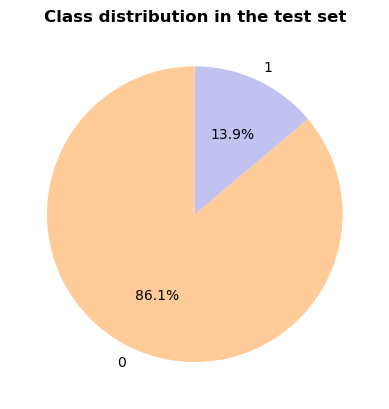

In [27]:
test_label.value_counts().plot.pie(autopct='%1.1f%%', labels=['0', '1'], colors=["#ffcc99", "#c2c2f0"], startangle=90)
plt.title("Class distribution in the test set", fontweight='bold')
plt.ylabel('')

In [28]:
distributional_explanations.describe().drop("count", axis="rows")

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
mean,-0.008128,-0.053219,0.007508,-0.007954,-0.009874,-0.005716,0.013909,-0.009306,-0.036149,-0.018008,-0.028215,-0.002260
std,0.029591,0.030077,0.023075,0.015994,0.022008,0.030497,0.049197,0.021384,0.145801,0.026043,0.084448,0.006678
min,-0.202636,-0.157534,-0.106029,-0.250071,-0.212282,-0.239376,-0.121174,-0.105650,-0.242598,-0.168554,-0.212884,-0.045786
25%,-0.013846,-0.075518,-0.008321,-0.011804,-0.018215,-0.017298,-0.014109,-0.020784,-0.141914,-0.034330,-0.084064,-0.005491
50%,0.002537,-0.052332,0.006636,-0.006583,-0.008497,-0.000066,0.013137,-0.008893,-0.073689,-0.013352,-0.045921,-0.002479
75%,0.009126,-0.030225,0.027626,-0.002501,0.000250,0.010423,0.038142,0.001599,0.019321,0.000993,0.018277,0.000842
max,0.045999,0.065771,0.106410,0.087106,0.141170,0.112940,0.227183,0.100285,0.509609,0.063781,0.363474,0.074460


We notice that almost all the features have a negative mean contribution, caused by the fact that most of the test data is classified as 0.
The features _'AVG position_2021'_ and _'std_dev position_2021'_ are those with the highest maximum value, which means that for some instances those features had an important influence on the final prediction of class '1' (0.5 and 0.3 respectively). This observation is also confirmed by the highest standard deviation and range. The feature 'geo area' has the least standard deviation, confirming that is not a discriminative feature for the final prediction.


In [29]:
#REMOVE COMMENTS TO EXTRACT SINGLE PLOTS

# for column in distributional_explanations.columns:
#     plt.figure(figsize=(6, 4))
#     sbn.kdeplot(data=distributional_explanations, x=column)
#     plt.title(f"KDE Plot for the SHAP values of {column}", fontweight="bold")
#     plt.xlabel(column)
#     plt.ylabel("Density")
#     plt.grid(True)
#     plt.show()
#     plt.close()

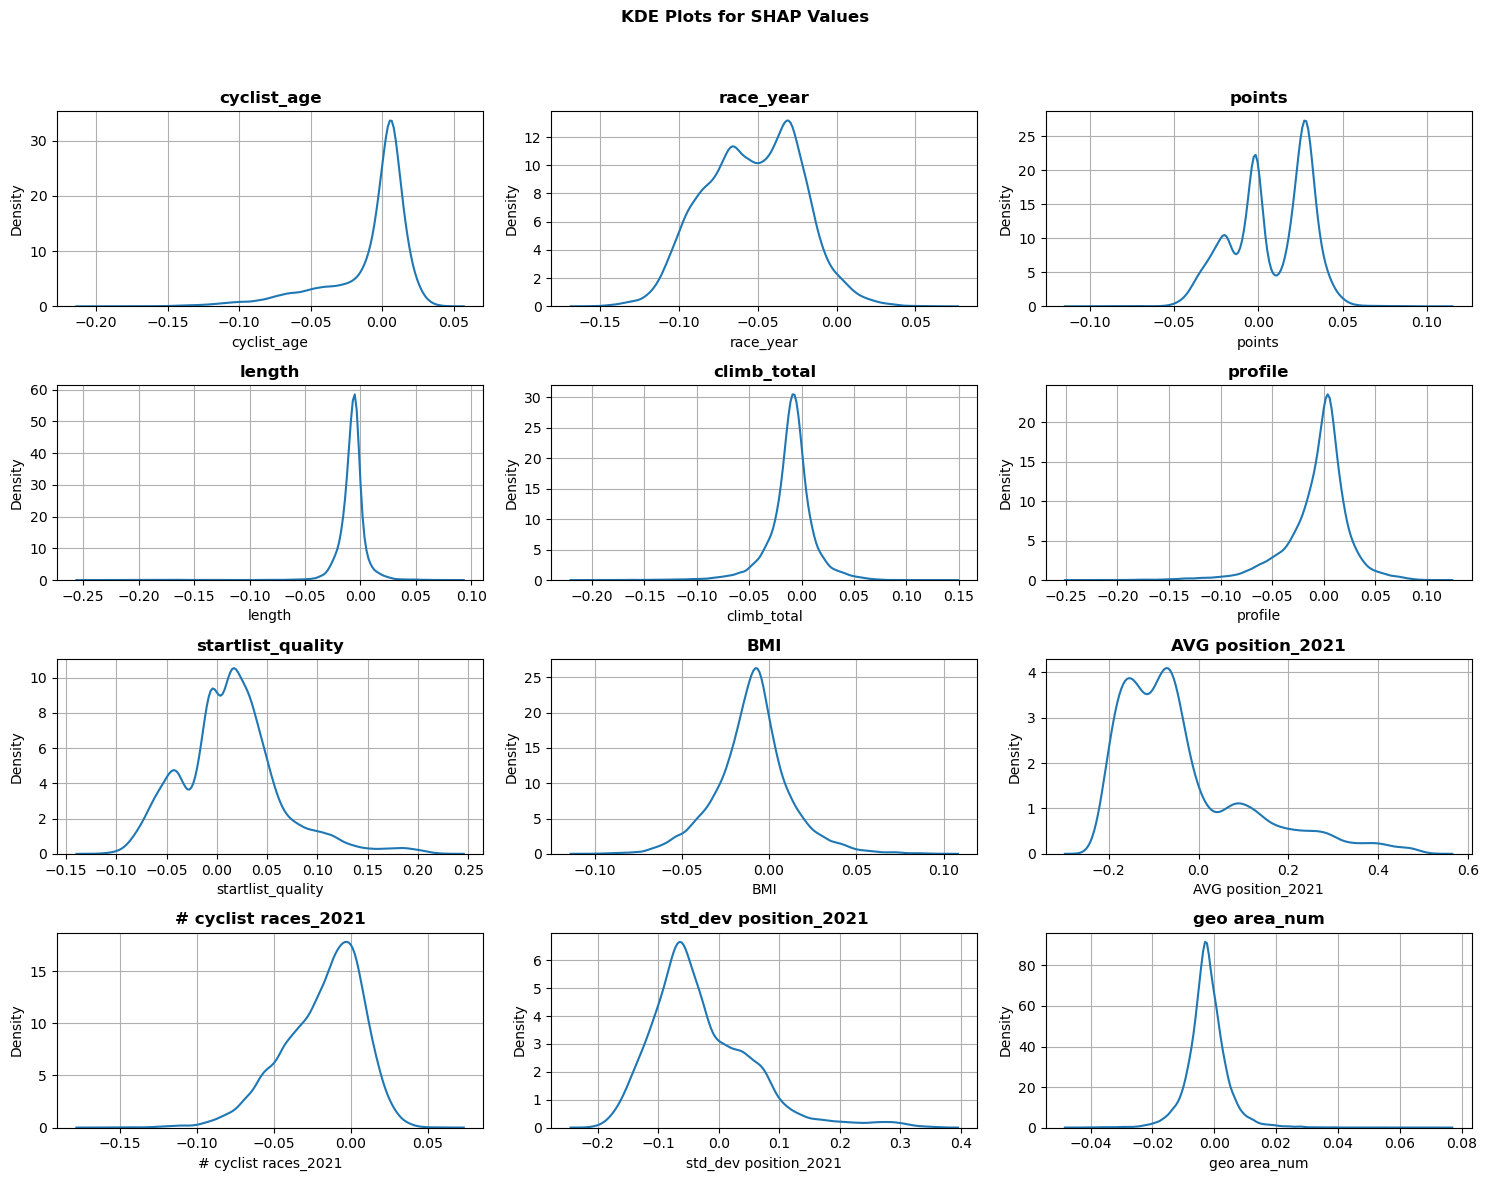

In [30]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # Converts a 2D grid in a 1D array to iterate

for i, column in enumerate(distributional_explanations.columns):
    sbn.kdeplot(data=distributional_explanations, x=column, ax=axes[i])
    axes[i].set_title(f"{column}", fontweight="bold")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Density")
    axes[i].grid(True)

fig.suptitle("KDE Plots for SHAP Values",fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Also this visualization confirms that the SHAP values are centered around 0, but the distribution is not symmetric. The distribution of the SHAP values is not uniform across the features, and some features have a higher variance than others.

In [31]:
number_quantiles = 40
quantiles = distributional_explanations["cyclist_age"].quantile([q / number_quantiles for q in (range(number_quantiles))])
quantiles.diff()  # pick differences in quantiles

0.000         NaN
0.025    0.110399
0.050    0.019229
0.075    0.011155
0.100    0.009570
0.125    0.007912
0.150    0.007126
0.175    0.006884
0.200    0.006192
0.225    0.005668
0.250    0.004654
0.275    0.003365
0.300    0.002650
0.325    0.002291
0.350    0.001730
0.375    0.001329
0.400    0.001147
0.425    0.001032
0.450    0.001078
0.475    0.000925
0.500    0.000839
0.525    0.000775
0.550    0.000733
0.575    0.000646
0.600    0.000641
0.625    0.000612
0.650    0.000583
0.675    0.000582
0.700    0.000620
0.725    0.000665
0.750    0.000733
0.775    0.000810
0.800    0.000913
0.825    0.000935
0.850    0.001126
0.875    0.001302
0.900    0.001366
0.925    0.001785
0.950    0.002429
0.975    0.003955
Name: cyclist_age, dtype: float64

**TODO**
Integrare con analisi magari focalizzate su una feature di interesse. (Loro non hanno selezionato quella più importante).
- For what instances are some features more/less impactful?
- What are the differences in instances for which the selected features is highly important?

### Validation
To validate this feature as the most relevant for the classification model, we check its sensitivity to perturbations.

In [32]:
mean_absolute_importances = distributional_explanations.abs().mean() #absolute value required because contributions have a sign +/-
features_by_importance = distributional_explanations.columns[mean_absolute_importances.argsort()].tolist()
features_by_importance
#AVG position_2021 is the most important feature

['geo area_num',
 'length',
 'climb_total',
 'BMI',
 'cyclist_age',
 'points',
 'profile',
 '# cyclist races_2021',
 'startlist_quality',
 'race_year',
 'std_dev position_2021',
 'AVG position_2021']

In [33]:
print_report(train_label=train_label_os, train_predictions=train_pred_rf, validation_label=test_label, valid_predictions=test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.94      0.93    402429
       top20       0.90      0.87      0.89    269627

    accuracy                           0.91    672056
   macro avg       0.91      0.90      0.91    672056
weighted avg       0.91      0.91      0.91    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.92      0.91     28066
       top20       0.46      0.43      0.44      4520

    accuracy                           0.85     32586
   macro avg       0.68      0.67      0.68     32586
weighted avg       0.85      0.85      0.85     32586



Let's generate a series of perturbated test set, in which we add a noise of different magnitude to the test instances, and let's see how the model performance changes.

In [34]:
validation = classification_report(test_label, test_pred_rf, output_dict=True)
validation = pd.DataFrame(validation)
validation

,0,1,accuracy,macro avg,weighted avg
precision,0.908498,0.457422,0.850304,0.682960,0.845930
recall,0.918727,0.425442,0.850304,0.672085,0.850304
f1-score,0.913584,0.440853,0.850304,0.677219,0.848012
support,28066.000000,4520.000000,0.850304,32586.000000,32586.000000


In [35]:
# Generates an array of noise in the range [0, 1] with the same shape as the test set
random_noise = np.random.rand(test_set.shape[0],) # Random noise from a normal distribution

# We generate a list of noise magnitudes to test from (0.1, 0.2, ..., 0.9)
noise_magnitudes = [eps / 10 for eps in range(1, 10)]

We expect that adding a random noise to the relevant feature will have an impact on performance of the classifier. So we follow this strategy:
- First, we generate artificial noise on the test data.
- Then we predict the perturbed test data using the Random Forest classifier.
- We compare the evaluation metrics of the classifier applied to the original and the perturbed test set.

In [36]:
features_by_importance.remove("profile")
features_by_importance.remove("geo area_num")

In [37]:
features_by_importance

['length',
 'climb_total',
 'BMI',
 'cyclist_age',
 'points',
 '# cyclist races_2021',
 'startlist_quality',
 'race_year',
 'std_dev position_2021',
 'AVG position_2021']

Notice that the corruption on the attribute 'geo area_num' are not so meaningful, since this column is an encoding of a categorical feature. The same reasoning applies to the 'profile' feature, which is an ordinal.

In [38]:
corruptions_by_feature_and_noise = dict()
for feature in features_by_importance:
    for noise_magnitude in noise_magnitudes:
        corruptions_by_feature_and_noise[(feature, noise_magnitude)] = test_set.copy()
        corruptions_by_feature_and_noise[(feature, noise_magnitude)][feature] += random_noise * noise_magnitude

In [39]:
validations_by_feature_and_noise = dict()
for (feature, noise), corruption in corruptions_by_feature_and_noise.items():
    validations_by_feature_and_noise[(feature, noise)] = classification_report(test_label, rf.predict(corruption), output_dict=True)

In [40]:
metric = "f1-score"
corruption_validation = pd.DataFrame([
    (feature, noise_magnitude, validations_by_feature_and_noise[(feature, noise_magnitude)]["weighted avg"][metric], "shap")
    for feature, noise_magnitude in validations_by_feature_and_noise
    ],
    columns=["feature", "noise_magnitude", "performance", "algorithm"]
)
corruption_validation["difference"] = corruption_validation["performance"] - validation["weighted avg"][metric]

In [41]:
pd.set_option('display.max_rows', None) 
corruption_validation

,feature,noise_magnitude,performance,algorithm,difference
0,length,0.1,0.848082,shap,0.000071
1,length,0.2,0.848082,shap,0.000071
2,length,0.3,0.848082,shap,0.000071
3,length,0.4,0.848082,shap,0.000071
4,length,0.5,0.848082,shap,0.000071
5,length,0.6,0.848082,shap,0.000071
6,length,0.7,0.848082,shap,0.000071
7,length,0.8,0.848082,shap,0.000071
8,length,0.9,0.848082,shap,0.000071
9,climb_total,0.1,0.847988,shap,-0.000024


In [42]:
noise_magnitudes = [2 ** eps for eps in range(0, 6)]  # Increase the magnitude of the noise: 1, 2, 4, 8, 16, 32

[autoreload of classification_utility failed: Traceback (most recent call last):
  File "c:\Users\simon\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\simon\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\simon\anaconda3\Lib\importlib\__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "c:\Users\simon\Desktop\Data Mining\Progetto\RepoCondivisa\dm-2024-project\notebook\../src\classification_utility.py", line 13, in <module>
    import tensorflow as tf
ModuleNotFoundError: No module named 'tensorflow'
]


In [43]:
corruptions_by_feature_and_noise = dict()
for feature in features_by_importance:
    for noise_magnitude in noise_magnitudes:
        corruptions_by_feature_and_noise[(feature, noise_magnitude)] = test_set.copy()
        corruptions_by_feature_and_noise[(feature, noise_magnitude)][feature] += random_noise * noise_magnitude
validations_by_feature_and_noise = dict()
for (feature, noise), corruption in corruptions_by_feature_and_noise.items():
    validations_by_feature_and_noise[(feature, noise)] = classification_report(test_label, rf.predict(corruption), output_dict=True)
metric = "f1-score"
corruption_validation = pd.DataFrame([
    (feature, noise_magnitude, validations_by_feature_and_noise[(feature, noise_magnitude)]["weighted avg"][metric], "shap")
    for feature, noise_magnitude in validations_by_feature_and_noise
    ],
    columns=["feature", "noise_magnitude", "performance", "algorithm"]
)
corruption_validation["difference"] = corruption_validation["performance"] - validation["weighted avg"][metric]    

In [44]:
corruption_validation

,feature,noise_magnitude,performance,algorithm,difference
0,length,1,0.848082,shap,0.000071
1,length,2,0.848082,shap,0.000071
2,length,4,0.848082,shap,0.000071
3,length,8,0.848082,shap,0.000071
4,length,16,0.848082,shap,0.000071
5,length,32,0.848082,shap,0.000071
6,climb_total,1,0.847988,shap,-0.000024
7,climb_total,2,0.847934,shap,-0.000077
8,climb_total,4,0.848151,shap,0.000140
9,climb_total,8,0.848150,shap,0.000138


In [45]:
pd.reset_option('display.max_rows')

It can be seen that by increasing the amount of noise, the performance of the model decreases, especially for the feature 'AVG position_2021'. This is to be expected as the noise is added to the most important features according to the SHAP values. Actually, in the first attempt to add noise, there was no significant decrease in performance for the most relevant feature. This may be because the model itself is more robust to noise (as in the case of ensemble methods) or because the noise added was too small.

In [46]:
corruption_validation.groupby("feature").describe()[["performance", "difference"]]

performance                                          \
                            count      mean       std       min       25%   
feature                                                                     
# cyclist races_2021          6.0  0.847769  0.000225  0.847515  0.847566   
AVG position_2021             6.0  0.844515  0.006437  0.832568  0.843010   
BMI                           6.0  0.841631  0.003274  0.838317  0.839506   
climb_total                   6.0  0.847984  0.000158  0.847727  0.847939   
cyclist_age                   6.0  0.845685  0.003778  0.840659  0.842595   
length                        6.0  0.848082  0.000000  0.848082  0.848082   
points                        6.0  0.847732  0.000481  0.846840  0.847634   
race_year                     6.0  0.848012  0.000000  0.848012  0.848012   
startlist_quality             6.0  0.848120  0.000282  0.847848  0.847975   
std_dev position_2021         6.0  0.818127  0.039835  0.745891  0.806115   

                                                    difference            \
                            50%       75%       max      count      mean   
feature                                                                    
# cyclist races_2021   0.847781  0.847968  0.848012        6.0 -0.000243   
AVG position_2021      0.847735  0.848624  0.848697        6.0 -0.003497   
BMI                    0.840458  0.843535  0.846804        6.0 -0.006381   
climb_total            0.847970  0.848109  0.848151        6.0 -0.000028   
cyclist_age            0.847080  0.848172  0.849656        6.0 -0.002327   
length                 0.848082  0.848082  0.848082        6.0  0.000071   
points                 0.848012  0.848012  0.848012        6.0 -0.000279   
race_year              0.848012  0.848012  0.848012        6.0  0.000000   
startlist_quality      0.847986  0.848256  0.848586        6.0  0.000109   
std_dev position_2021  0.835502  0.844991  0.847397        6.0 -0.029884   

                                                                         \
                            std       min       25%       50%       75%   
feature                                                                   
# cyclist races_2021   0.000225 -0.000497 -0.000446 -0.000230 -0.000043   
AVG position_2021      0.006437 -0.015444 -0.005002 -0.000277  0.000613   
BMI                    0.003274 -0.009695 -0.008506 -0.007554 -0.004477   
climb_total            0.000158 -0.000285 -0.000073 -0.000041  0.000098   
cyclist_age            0.003778 -0.007353 -0.005417 -0.000932  0.000160   
length                 0.000000  0.000071  0.000071  0.000071  0.000071   
points                 0.000481 -0.001171 -0.000378  0.000000  0.000000   
race_year              0.000000  0.000000  0.000000  0.000000  0.000000   
startlist_quality      0.000282 -0.000163 -0.000037 -0.000026  0.000244   
std_dev position_2021  0.039835 -0.102121 -0.041897 -0.012510 -0.003021   

                                 
                            max  
feature                          
# cyclist races_2021   0.000000  
AVG position_2021      0.000685  
BMI                   -0.001208  
climb_total            0.000140  
cyclist_age            0.001645  
length                 0.000071  
points                 0.000000  
race_year              0.000000  
startlist_quality      0.000574  
std_dev position_2021 -0.000615

In [47]:
corruption_validation.groupby("noise_magnitude").describe()[["performance", "difference"]]

performance                                                    \
                      count      mean       std       min       25%       50%   
noise_magnitude                                                                 
1                      10.0  0.847911  0.000490  0.846804  0.847977  0.848012   
2                      10.0  0.847688  0.001440  0.844301  0.847870  0.847996   
4                      10.0  0.846643  0.002954  0.840892  0.847598  0.848012   
8                      10.0  0.845027  0.005869  0.830111  0.846287  0.847754   
16                     10.0  0.840886  0.015400  0.798116  0.841502  0.847730   
32                     10.0  0.834439  0.031579  0.745891  0.838902  0.847277   

                                    difference                                \
                      75%       max      count      mean       std       min   
noise_magnitude                                                                
1                0.848065  0.848625       10.0 -0.000100  0.000490 -0.001208   
2                0.848065  0.849656       10.0 -0.000324  0.001440 -0.003711   
4                0.848077  0.848622       10.0 -0.001368  0.002954 -0.007119   
8                0.848012  0.848150       10.0 -0.002985  0.005869 -0.017901   
16               0.848011  0.848344       10.0 -0.007126  0.015400 -0.049896   
32               0.847940  0.848586       10.0 -0.013572  0.031579 -0.102121   

                                                             
                      25%       50%           75%       max  
noise_magnitude                                              
1               -0.000035  0.000000  5.307224e-05  0.000614  
2               -0.000142 -0.000016  5.307224e-05  0.001645  
4               -0.000414  0.000000  6.521933e-05  0.000610  
8               -0.001725 -0.000258  0.000000e+00  0.000138  
16              -0.006509 -0.000282 -8.788178e-07  0.000332  
32              -0.009109 -0.000734 -7.118943e-05  0.000574

## Local interpretability

# LORIS

In [ ]:
interaction_values = rf_explainer.shap_values(test_set)

In [ ]:
# interaction_values

In [ ]:
# Save the SHAP values in a file
# dump(interaction_values, "interaction_values_distributional.joblib")

In [ ]:
# Load the SHAP values from a file
shap_values = load("interaction_values_distributional.joblib")